In [22]:
# Load dataset
import pandas as pd

df = pd.read_csv(r"C:\Users\Aditya kumar\Desktop\goalzen\archive\ADANIPORTS.csv")
print(df.head())
print(df.info())
print(df.describe())

         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.875200e+14     NaN              816123   

   %Deliverble  
0       0.3612  
1       0.3172  
2       0.2088  
3       0.2735  
4

In [23]:
#Convert Date column to datetime and sort by Symbol and Date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

In [24]:
#Forward-fill last valid prices for each symbol
df[['Open','High','Low','Close']] = df.groupby('Symbol')[['Open','High','Low','Close']].ffill()
print(df.head(10))


        Date      Symbol Series  Prev Close    Open    High     Low    Last  \
0 2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00  140.10   
1 2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70  143.00   
2 2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15  149.50   
3 2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25  155.40   
4 2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10  146.40   
5 2012-01-24  ADANIPORTS     EQ      146.75  147.05  152.90  145.60  149.80   
6 2012-01-25  ADANIPORTS     EQ      150.05  150.95  150.95  142.25  144.35   
7 2012-01-27  ADANIPORTS     EQ      143.20  145.80  149.65  144.80  146.75   
8 2012-01-30  ADANIPORTS     EQ      147.10  147.10  147.40  137.35  138.40   
9 2012-01-31  ADANIPORTS     EQ      138.40  138.95  148.50  137.00  147.10   

    Close    VWAP   Volume      Turnover   Trades  Deliverable Volume  \
0  140.00  138.13  1636196  2.260074e+13  18374.0        

In [25]:
#Remove duplicates based on Date and Symbol
df = df.drop_duplicates(subset=['Date', 'Symbol'])
print(df.head(10))

        Date      Symbol Series  Prev Close    Open    High     Low    Last  \
0 2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00  140.10   
1 2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70  143.00   
2 2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15  149.50   
3 2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25  155.40   
4 2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10  146.40   
5 2012-01-24  ADANIPORTS     EQ      146.75  147.05  152.90  145.60  149.80   
6 2012-01-25  ADANIPORTS     EQ      150.05  150.95  150.95  142.25  144.35   
7 2012-01-27  ADANIPORTS     EQ      143.20  145.80  149.65  144.80  146.75   
8 2012-01-30  ADANIPORTS     EQ      147.10  147.10  147.40  137.35  138.40   
9 2012-01-31  ADANIPORTS     EQ      138.40  138.95  148.50  137.00  147.10   

    Close    VWAP   Volume      Turnover   Trades  Deliverable Volume  \
0  140.00  138.13  1636196  2.260074e+13  18374.0        

In [26]:
#Remove rows with non-positive Open or Close prices
df = df[(df['Open'] > 0) & (df['Close'] > 0)]

from scipy import stats
df = df[(abs(stats.zscore(df['Close'])) < 3)]
print(df.head(10))

        Date      Symbol Series  Prev Close    Open    High     Low    Last  \
0 2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00  140.10   
1 2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70  143.00   
2 2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15  149.50   
3 2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25  155.40   
4 2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10  146.40   
5 2012-01-24  ADANIPORTS     EQ      146.75  147.05  152.90  145.60  149.80   
6 2012-01-25  ADANIPORTS     EQ      150.05  150.95  150.95  142.25  144.35   
7 2012-01-27  ADANIPORTS     EQ      143.20  145.80  149.65  144.80  146.75   
8 2012-01-30  ADANIPORTS     EQ      147.10  147.10  147.40  137.35  138.40   
9 2012-01-31  ADANIPORTS     EQ      138.40  138.95  148.50  137.00  147.10   

    Close    VWAP   Volume      Turnover   Trades  Deliverable Volume  \
0  140.00  138.13  1636196  2.260074e+13  18374.0        

In [27]:
# Save cleaned data
df.to_csv("cleaned_equities.csv", index=False)

In [28]:
# Further processing on cleaned data
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_equities.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)


In [29]:
# 20-day and 50-day Moving Averages
df['SMA_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=20).mean())
df['EMA_20'] = df.groupby('Symbol')['Close'].transform(lambda x: x.ewm(span=20, adjust=False).mean())
print(df.head(10))

        Date      Symbol Series  Prev Close    Open    High     Low    Last  \
0 2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00  140.10   
1 2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70  143.00   
2 2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15  149.50   
3 2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25  155.40   
4 2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10  146.40   
5 2012-01-24  ADANIPORTS     EQ      146.75  147.05  152.90  145.60  149.80   
6 2012-01-25  ADANIPORTS     EQ      150.05  150.95  150.95  142.25  144.35   
7 2012-01-27  ADANIPORTS     EQ      143.20  145.80  149.65  144.80  146.75   
8 2012-01-30  ADANIPORTS     EQ      147.10  147.10  147.40  137.35  138.40   
9 2012-01-31  ADANIPORTS     EQ      138.40  138.95  148.50  137.00  147.10   

    Close    VWAP   Volume      Turnover   Trades  Deliverable Volume  \
0  140.00  138.13  1636196  2.260074e+13  18374.0        

In [30]:
# Relative Strength Index (RSI) Calculation
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI_14'] = df.groupby('Symbol')['Close'].transform(lambda x: compute_rsi(x))
print(df.head(10))

        Date      Symbol Series  Prev Close    Open    High     Low    Last  \
0 2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00  140.10   
1 2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70  143.00   
2 2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15  149.50   
3 2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25  155.40   
4 2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10  146.40   
5 2012-01-24  ADANIPORTS     EQ      146.75  147.05  152.90  145.60  149.80   
6 2012-01-25  ADANIPORTS     EQ      150.05  150.95  150.95  142.25  144.35   
7 2012-01-27  ADANIPORTS     EQ      143.20  145.80  149.65  144.80  146.75   
8 2012-01-30  ADANIPORTS     EQ      147.10  147.10  147.40  137.35  138.40   
9 2012-01-31  ADANIPORTS     EQ      138.40  138.95  148.50  137.00  147.10   

    Close    VWAP   Volume      Turnover   Trades  Deliverable Volume  \
0  140.00  138.13  1636196  2.260074e+13  18374.0        

In [31]:
# Bollinger Bands Calculation
rolling_mean = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=20).mean())
rolling_std = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=20).std())

df['Bollinger_Upper'] = rolling_mean + (rolling_std * 2)
df['Bollinger_Lower'] = rolling_mean - (rolling_std * 2)
print(df.head(10))

        Date      Symbol Series  Prev Close    Open    High     Low    Last  \
0 2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00  140.10   
1 2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70  143.00   
2 2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15  149.50   
3 2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25  155.40   
4 2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10  146.40   
5 2012-01-24  ADANIPORTS     EQ      146.75  147.05  152.90  145.60  149.80   
6 2012-01-25  ADANIPORTS     EQ      150.05  150.95  150.95  142.25  144.35   
7 2012-01-27  ADANIPORTS     EQ      143.20  145.80  149.65  144.80  146.75   
8 2012-01-30  ADANIPORTS     EQ      147.10  147.10  147.40  137.35  138.40   
9 2012-01-31  ADANIPORTS     EQ      138.40  138.95  148.50  137.00  147.10   

    Close    VWAP   Volume      Turnover   Trades  Deliverable Volume  \
0  140.00  138.13  1636196  2.260074e+13  18374.0        

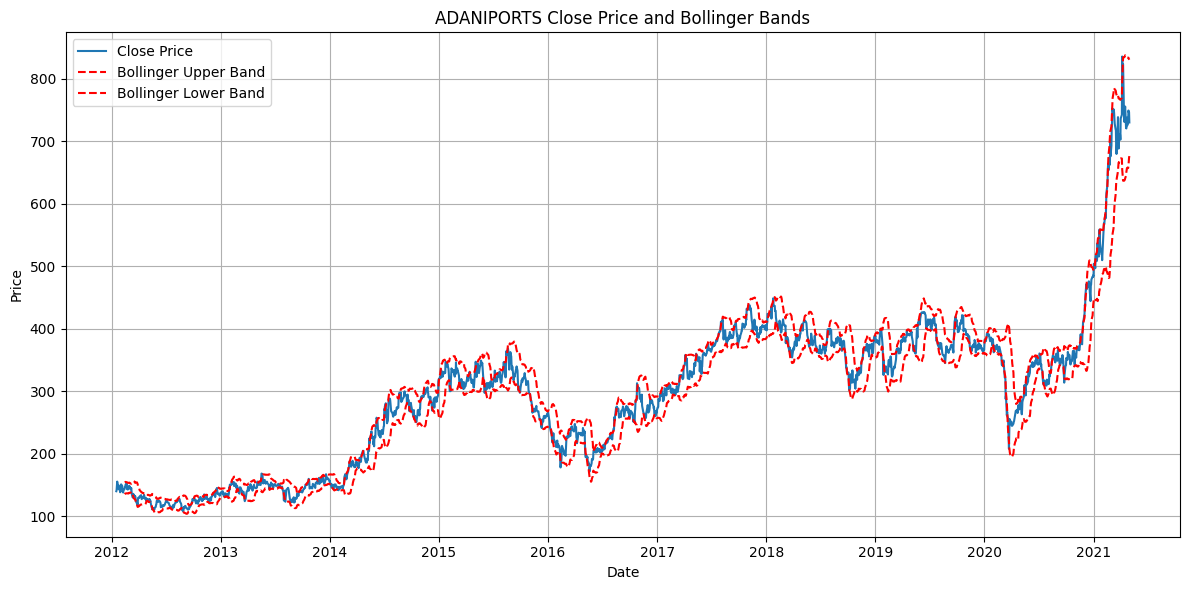

In [32]:
# Visualization of Bollinger Bands for a sample symbol
import matplotlib.pyplot as plt

# Choose a symbol to visualize
symbol_to_plot = 'ADANIPORTS'

# Filter the DataFrame for the selected symbol
df_plot = df[df['Symbol'] == symbol_to_plot].copy()

# Create a figure and axes
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the Close price and Bollinger Bands
ax.plot(df_plot['Date'], df_plot['Close'], label='Close Price')
ax.plot(df_plot['Date'], df_plot['Bollinger_Upper'], label='Bollinger Upper Band', color='red', linestyle='--')
ax.plot(df_plot['Date'], df_plot['Bollinger_Lower'], label='Bollinger Lower Band', color='red', linestyle='--')

ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_title(f'{symbol_to_plot} Close Price and Bollinger Bands')
ax.legend()
ax.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [33]:
# Volatility Calculation (Rolling Standard Deviation of Returns)
df['Return'] = df.groupby('Symbol')['Close'].pct_change()
df['Lag1_Return'] = df.groupby('Symbol')['Return'].shift(1)
df['Volatility_10'] = df.groupby('Symbol')['Return'].transform(lambda x: x.rolling(window=10).std())
print(df.head(10))

        Date      Symbol Series  Prev Close    Open    High     Low    Last  \
0 2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00  140.10   
1 2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70  143.00   
2 2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15  149.50   
3 2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25  155.40   
4 2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10  146.40   
5 2012-01-24  ADANIPORTS     EQ      146.75  147.05  152.90  145.60  149.80   
6 2012-01-25  ADANIPORTS     EQ      150.05  150.95  150.95  142.25  144.35   
7 2012-01-27  ADANIPORTS     EQ      143.20  145.80  149.65  144.80  146.75   
8 2012-01-30  ADANIPORTS     EQ      147.10  147.10  147.40  137.35  138.40   
9 2012-01-31  ADANIPORTS     EQ      138.40  138.95  148.50  137.00  147.10   

    Close    VWAP  ...  Deliverable Volume  %Deliverble  SMA_20      EMA_20  \
0  140.00  138.13  ...             1004327       0.

In [34]:
# MACD Calculation
def compute_macd(series, short=12, long=26, signal=9):
    ema_short = series.ewm(span=short, adjust=False).mean()
    ema_long = series.ewm(span=long, adjust=False).mean()
    macd = ema_short - ema_long
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

macd = []
signal_line = []

for _, group in df.groupby('Symbol')['Close']:
    m, s = compute_macd(group)
    macd.extend(m)
    signal_line.extend(s)

df['MACD'] = macd
df['MACD_signal'] = signal_line

print(df)

           Date      Symbol Series  Prev Close    Open    High     Low  \
0    2012-01-17  ADANIPORTS     EQ      135.50  137.10  141.00  135.00   
1    2012-01-18  ADANIPORTS     EQ      140.00  142.00  143.80  138.70   
2    2012-01-19  ADANIPORTS     EQ      141.70  144.00  150.55  143.15   
3    2012-01-20  ADANIPORTS     EQ      149.40  151.90  157.60  150.25   
4    2012-01-23  ADANIPORTS     EQ      155.40  155.40  155.40  145.10   
...         ...         ...    ...         ...     ...     ...     ...   
3283 2012-01-10  MUNDRAPORT     EQ      132.20  133.85  137.00  132.85   
3284 2012-01-11  MUNDRAPORT     EQ      136.45  136.00  140.70  134.75   
3285 2012-01-12  MUNDRAPORT     EQ      137.05  137.50  137.50  131.20   
3286 2012-01-13  MUNDRAPORT     EQ      132.65  132.50  133.00  129.55   
3287 2012-01-16  MUNDRAPORT     EQ      131.55  131.50  136.40  130.65   

        Last   Close    VWAP  ...    SMA_20      EMA_20     RSI_14  \
0     140.10  140.00  138.13  ...       N

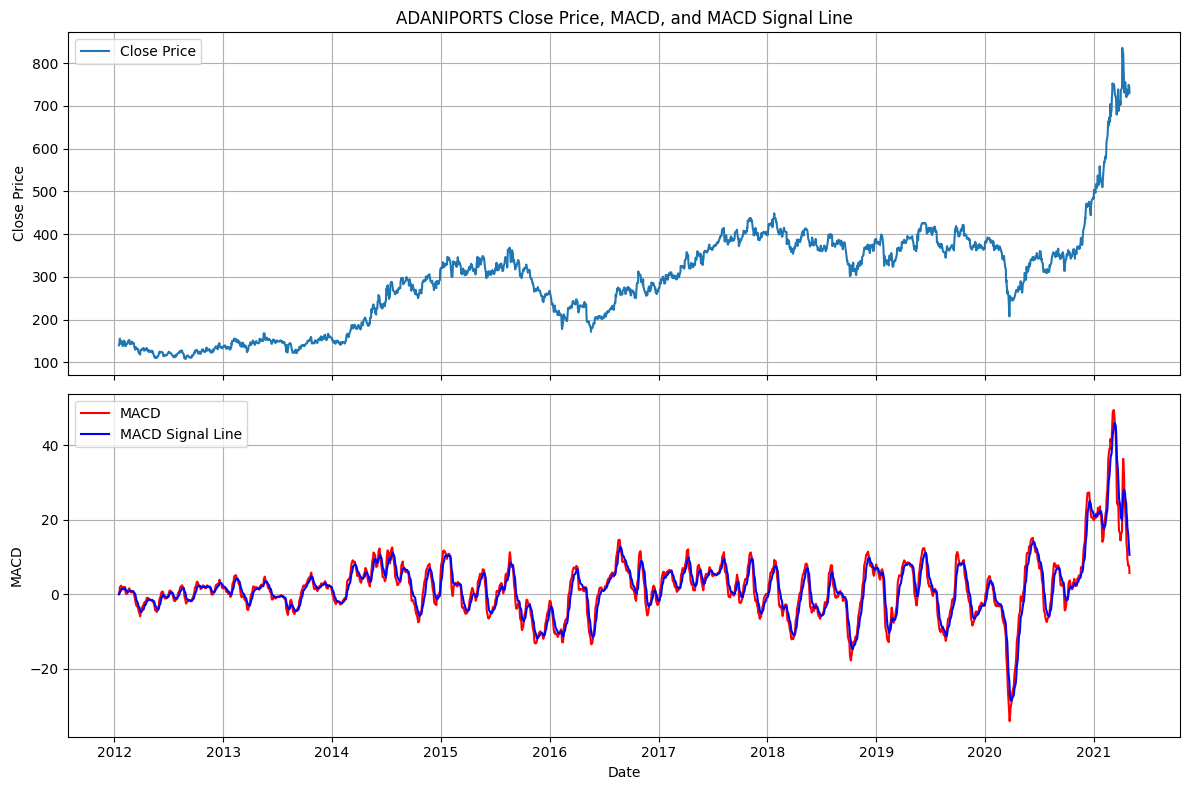

In [35]:
# Visualization of MACD for a sample symbol
import matplotlib.pyplot as plt

# Choose a symbol to visualize
symbol_to_plot = 'ADANIPORTS'  # You can change this to 'MUNDRAPORT'

# Filter the DataFrame for the selected symbol
df_plot = df[df['Symbol'] == symbol_to_plot].copy()

# Create a figure and a set of subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot the Close price on the first subplot
ax1.plot(df_plot['Date'], df_plot['Close'], label='Close Price')
ax1.set_ylabel('Close Price')
ax1.set_title(f'{symbol_to_plot} Close Price, MACD, and MACD Signal Line')
ax1.legend()
ax1.grid(True)

# Plot the MACD and MACD Signal Line on the second subplot
ax2.plot(df_plot['Date'], df_plot['MACD'], label='MACD', color='red')
ax2.plot(df_plot['Date'], df_plot['MACD_signal'], label='MACD Signal Line', color='blue')
ax2.set_ylabel('MACD')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [36]:
# Final cleanup and save
df = df.dropna().reset_index(drop=True)
df.to_csv("equities_with_features.csv", index=False)
print(df.head(10))

        Date      Symbol Series  Prev Close    Open    High     Low    Last  \
0 2012-02-14  ADANIPORTS     EQ      143.05  143.30  145.55  142.00  143.80   
1 2012-02-15  ADANIPORTS     EQ      144.15  145.00  147.95  144.15  146.60   
2 2012-02-16  ADANIPORTS     EQ      147.15  147.45  149.90  145.75  147.25   
3 2012-02-17  ADANIPORTS     EQ      147.60  149.00  152.90  145.75  151.50   
4 2012-02-21  ADANIPORTS     EQ      150.50  151.20  155.75  150.65  152.35   
5 2012-02-22  ADANIPORTS     EQ      152.65  155.75  157.75  142.40  143.50   
6 2012-02-23  ADANIPORTS     EQ      143.85  142.00  145.40  140.50  144.95   
7 2012-02-24  ADANIPORTS     EQ      144.05  145.05  146.50  141.00  142.25   
8 2012-02-27  ADANIPORTS     EQ      142.70  144.40  145.15  137.25  142.70   
9 2012-02-28  ADANIPORTS     EQ      143.65  144.80  149.45  144.10  148.65   

    Close    VWAP  ...    SMA_20      EMA_20     RSI_14  Bollinger_Upper  \
0  144.15  143.20  ...  144.9500  143.557864  44.93996

Train shape: (1949, 10) Test shape: (488, 10)
Train positive rate: 0.4976911236531555 Test positive rate: 0.5122950819672131
--- LogisticRegression ---
Accuracy: 0.47540983606557374
Precision: 0.488
Recall: 0.488
F1: 0.488
ROC AUC: 0.48393277310924365
Confusion matrix:
 [[110 128]
 [128 122]]
              precision    recall  f1-score   support

           0       0.46      0.46      0.46       238
           1       0.49      0.49      0.49       250

    accuracy                           0.48       488
   macro avg       0.48      0.48      0.48       488
weighted avg       0.48      0.48      0.48       488




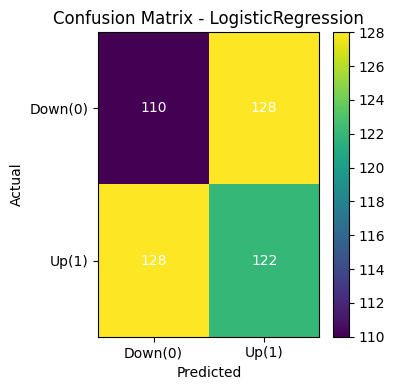

--- RandomForest ---
Accuracy: 0.5
Precision: 0.5138888888888888
Recall: 0.444
F1: 0.47639484978540775
ROC AUC: 0.504
Confusion matrix:
 [[133 105]
 [139 111]]
              precision    recall  f1-score   support

           0       0.49      0.56      0.52       238
           1       0.51      0.44      0.48       250

    accuracy                           0.50       488
   macro avg       0.50      0.50      0.50       488
weighted avg       0.50      0.50      0.50       488




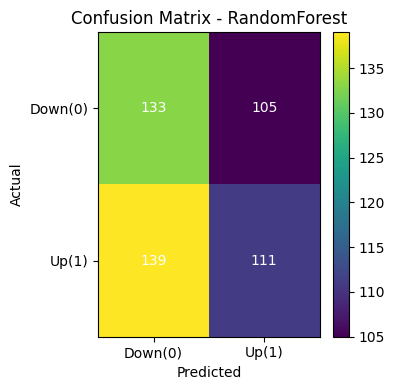

--- XGBoost ---
Accuracy: 0.5061475409836066
Precision: 0.5243243243243243
Recall: 0.388
F1: 0.4459770114942529
ROC AUC: 0.4944201680672269
Confusion matrix:
 [[150  88]
 [153  97]]
              precision    recall  f1-score   support

           0       0.50      0.63      0.55       238
           1       0.52      0.39      0.45       250

    accuracy                           0.51       488
   macro avg       0.51      0.51      0.50       488
weighted avg       0.51      0.51      0.50       488




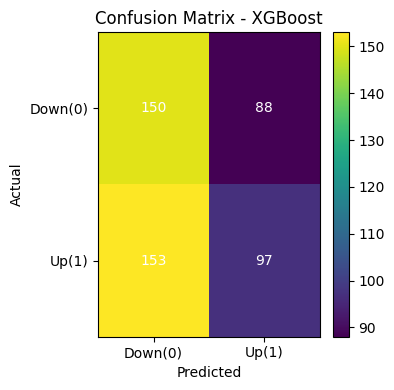

--- SVM_RBF ---
Accuracy: 0.4733606557377049
Precision: 0.4867924528301887
Recall: 0.516
F1: 0.5009708737864078
ROC AUC: 0.48069747899159665
Confusion matrix:
 [[102 136]
 [121 129]]
              precision    recall  f1-score   support

           0       0.46      0.43      0.44       238
           1       0.49      0.52      0.50       250

    accuracy                           0.47       488
   macro avg       0.47      0.47      0.47       488
weighted avg       0.47      0.47      0.47       488




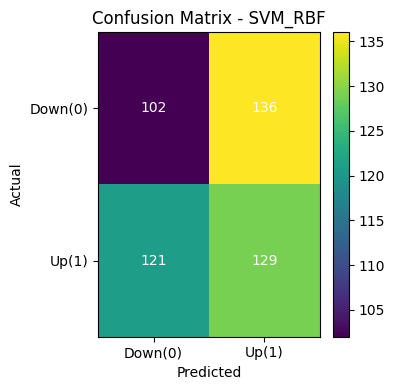

--- LightGBM ---
Accuracy: 0.5061475409836066
Precision: 0.5243243243243243
Recall: 0.388
F1: 0.4459770114942529
ROC AUC: 0.4944201680672269
Confusion matrix:
 [[150  88]
 [153  97]]
              precision    recall  f1-score   support

           0       0.50      0.63      0.55       238
           1       0.52      0.39      0.45       250

    accuracy                           0.51       488
   macro avg       0.51      0.51      0.50       488
weighted avg       0.51      0.51      0.50       488




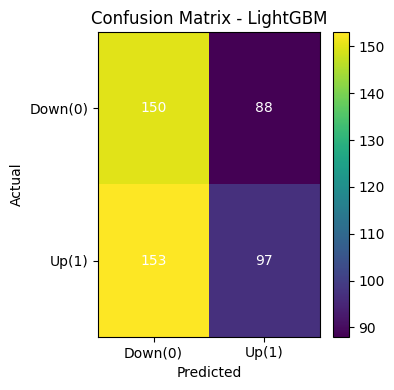

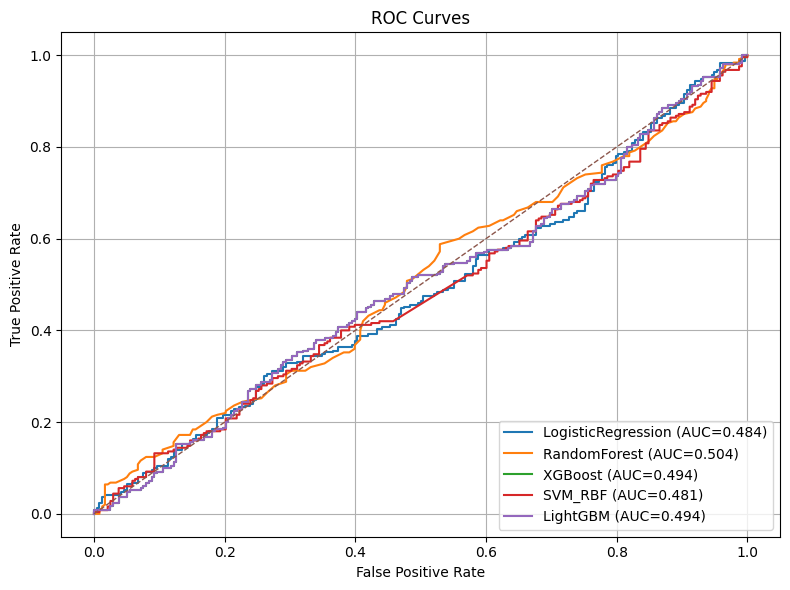

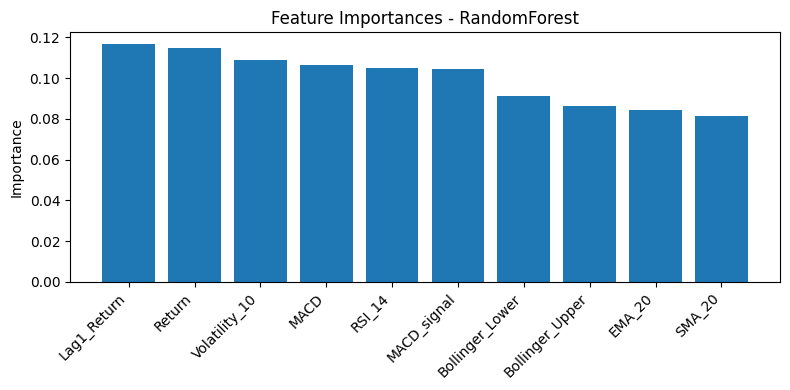

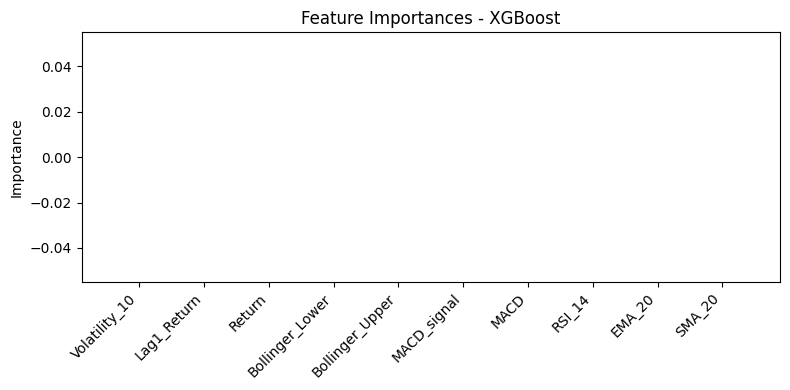

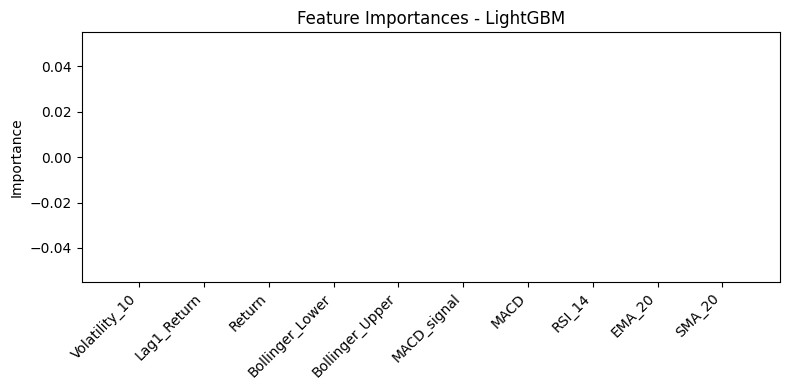

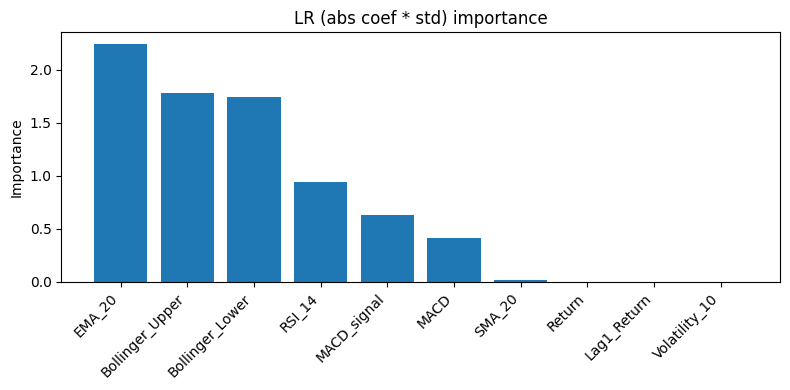


✅ All plots saved to 'ml_results_plots' and displayed successfully.


In [40]:
# ml_train_with_visuals_display.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
# prefer xgboost if installed, otherwise fall back to a scikit-learn booster
try:
    from xgboost import XGBClassifier
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier

    class XGBClassifier:
        """
        Lightweight fallback wrapper that mimics the XGBClassifier API enough for this notebook.
        Internally uses HistGradientBoostingClassifier when xgboost is not available.
        """
        def __init__(self, n_estimators=100, learning_rate=0.1, random_state=None,
                     use_label_encoder=None, eval_metric=None, scale_pos_weight=None, n_jobs=None):
            # HistGradientBoostingClassifier uses max_iter for number of trees
            self._model = HistGradientBoostingClassifier(
                max_iter=n_estimators,
                learning_rate=learning_rate,
                random_state=random_state
            )

        def fit(self, X, y, **kwargs):
            return self._model.fit(X, y)

        def predict(self, X):
            return self._model.predict(X)

        def predict_proba(self, X):
            # HGB has predict_proba
            return self._model.predict_proba(X)

        @property
        def feature_importances_(self):
            try:
                return self._model.feature_importances_
            except AttributeError:
                # if not available, return zeros
                import numpy as _np
                return _np.zeros(self._model.n_features_in_)
try:
    from lightgbm import LGBMClassifier
except ImportError:
    # fallback: use HistGradientBoostingClassifier with similar API
    class LGBMClassifier:
        def __init__(self, n_estimators=100, learning_rate=0.1, random_state=None,
                     class_weight=None, n_jobs=None):
            self._model = HistGradientBoostingClassifier(
                max_iter=n_estimators,
                learning_rate=learning_rate,
                random_state=random_state
            )

        def fit(self, X, y, **kwargs):
            return self._model.fit(X, y)

        def predict(self, X):
            return self._model.predict(X)

        def predict_proba(self, X):
            return self._model.predict_proba(X)

        @property
        def feature_importances_(self):
            try:
                return self._model.feature_importances_
            except AttributeError:
                import numpy as _np
                return _np.zeros(self._model.n_features_in_)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc, classification_report
)
from sklearn.inspection import permutation_importance

# ---------- CONFIG ----------
CSV_PATH = "equities_with_features.csv"
FEATURES = [
    'SMA_20', 'EMA_20', 'RSI_14', 'MACD', 'MACD_signal',
    'Bollinger_Upper', 'Bollinger_Lower', 'Return', 'Lag1_Return', 'Volatility_10'
]
TEST_RATIO = 0.20
RANDOM_STATE = 42
OUTPUT_DIR = "ml_results_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- 1) Load & prepare ----------
df = pd.read_csv(CSV_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

# create next-day direction target
df['Next_Close'] = df.groupby('Symbol')['Close'].shift(-1)
df['Direction'] = (df['Next_Close'] > df['Close']).astype(int)
df = df.dropna(subset=FEATURES + ['Direction']).reset_index(drop=True)

# time-based per-symbol split
train_parts, test_parts = [], []
for symbol, g in df.groupby('Symbol', sort=True):
    g = g.sort_values('Date')
    n = len(g)
    if n < 10:
        train_parts.append(g)
        continue
    split_idx = int(np.floor((1 - TEST_RATIO) * n))
    if split_idx < 1:
        split_idx = 1
    train_parts.append(g.iloc[:split_idx])
    test_parts.append(g.iloc[split_idx:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)

X_train = train_df[FEATURES].copy()
y_train = train_df['Direction'].astype(int).copy()
X_test  = test_df[FEATURES].copy()
y_test  = test_df['Direction'].astype(int).copy()

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train positive rate:", y_train.mean(), "Test positive rate:", y_test.mean())

# ---------- 2) Define & train models ----------
models = {}

# Logistic Regression (scaled)
models['LogisticRegression'] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])
models['LogisticRegression'].fit(X_train, y_train)

# Random Forest
models['RandomForest'] = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
models['RandomForest'].fit(X_train, y_train)

# XGBoost
num_pos = (y_train == 1).sum()
num_neg = (y_train == 0).sum()
scale_pos_weight = (num_neg / num_pos) if num_pos > 0 else 1.0

models['XGBoost'] = XGBClassifier(
    n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE,
    use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight, n_jobs=-1
)
models['XGBoost'].fit(X_train, y_train)

# SVM (RBF) - scaled and probability=True
models['SVM_RBF'] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE))
])
models['SVM_RBF'].fit(X_train, y_train)

# LightGBM
models['LightGBM'] = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE,
    class_weight='balanced', n_jobs=-1
)
models['LightGBM'].fit(X_train, y_train)

# Save models
for name, model in models.items():
    joblib.dump(model, f"{OUTPUT_DIR}/model_{name}.pkl")

# ---------- 3) Evaluation and plotting helpers ----------
def print_metrics(name, y_true, y_pred, y_proba=None):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1:", f1_score(y_true, y_pred, zero_division=0))
    if y_proba is not None and len(np.unique(y_true)) > 1:
        print("ROC AUC:", roc_auc_score(y_true, y_proba))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, zero_division=0))
    print()

# plot confusion matrix heatmap
def plot_confusion_matrix(cm, labels, title, outpath):
    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(cm, interpolation='nearest', aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

    # annotate counts
    thresh = cm.max() / 2.0 if cm.max() != 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(int(cm[i, j]), 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    fig.savefig(outpath, dpi=150)
    plt.show()  # <--- Display after saving

# plot ROC curves
def plot_rocs(model_results, outpath):
    plt.figure(figsize=(8,6))
    for name, res in model_results.items():
        if res['y_proba'] is None:
            continue
        fpr, tpr, _ = roc_curve(res['y_true'], res['y_proba'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    plt.show()  # <--- Display after saving

# feature importance
def plot_feature_importances(feature_names, importances, title, outpath, top_n=10):
    idx = np.argsort(importances)[::-1][:top_n]
    sorted_feats = [feature_names[i] for i in idx]
    sorted_imps = importances[idx]

    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(range(len(sorted_imps)), sorted_imps)
    ax.set_xticks(range(len(sorted_imps)))
    ax.set_xticklabels(sorted_feats, rotation=45, ha='right')
    ax.set_ylabel('Importance')
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(outpath, dpi=150)
    plt.show()  # <--- Display after saving

# ---------- 4) Evaluate each model ----------
model_results = {}
for name, model in models.items():
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    y_pred = model.predict(X_test)
    print_metrics(name, y_test, y_pred, y_proba)

    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(cm, labels=['Down(0)','Up(1)'],
                          title=f"Confusion Matrix - {name}",
                          outpath=f"{OUTPUT_DIR}/confmat_{name}.png")

    model_results[name] = {'y_true': y_test.values, 'y_pred': y_pred, 'y_proba': y_proba}

# ROC Curves (display + save)
plot_rocs(model_results, f"{OUTPUT_DIR}/roc_all_models.png")

# ---------- 5) Feature importance ----------
tree_models = ['RandomForest', 'XGBoost', 'LightGBM']
for tm in tree_models:
    model = models.get(tm)
    if model is None:
        continue
    try:
        importances = model.feature_importances_
    except Exception:
        perm = permutation_importance(model, X_test, y_test, n_repeats=20,
                                      random_state=RANDOM_STATE, n_jobs=-1)
        importances = perm.importances_mean

    plot_feature_importances(FEATURES, importances,
                             title=f"Feature Importances - {tm}",
                             outpath=f"{OUTPUT_DIR}/featimp_{tm}.png",
                             top_n=len(FEATURES))

# Logistic Regression feature importance
lr = models['LogisticRegression']
coef = lr.named_steps['clf'].coef_.ravel()
feat_std = X_train.std(axis=0).values
lr_importance = np.abs(coef * feat_std)
plot_feature_importances(FEATURES, lr_importance,
                         title="LR (abs coef * std) importance",
                         outpath=f"{OUTPUT_DIR}/featimp_LogisticRegression.png",
                         top_n=len(FEATURES))

print(f"\n✅ All plots saved to '{OUTPUT_DIR}' and displayed successfully.")


Dataset lengths -> total: 2437 train: 1949 test: 488
Features available: ['SMA_20', 'EMA_20', 'RSI_14', 'MACD', 'MACD_signal', 'Bollinger_Upper', 'Bollinger_Lower', 'Return', 'Lag1_Return', 'Volatility_10']
X_test sample:
         SMA_20      EMA_20     RSI_14      MACD  MACD_signal  Bollinger_Upper  \
1949  370.2925  371.496617  59.141631 -0.762847    -2.401789       380.326772   
1950  370.9975  372.544558  55.096419  0.173817    -1.886668       382.364695   
1951  371.7000  373.273648  62.305296  0.722214    -1.364892       383.532871   
1952  372.2600  374.371396  63.590772  1.510591    -0.789795       385.453364   
1953  373.1975  375.445548  61.749210  2.178856    -0.196065       387.412336   

      Bollinger_Lower    Return  Lag1_Return  Volatility_10  
1949       360.258228  0.014564     0.031831       0.014292  
1950       359.630305 -0.001696     0.014564       0.013364  
1951       359.867129 -0.006013    -0.001696       0.013610  
1952       359.066636  0.012099    -0.0060

C:\Users\Aditya kumar\AppData\Local\Temp\ipykernel_17332\3274500388.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=feature_df['MeanImportance'], y=feature_df.index, palette='viridis')


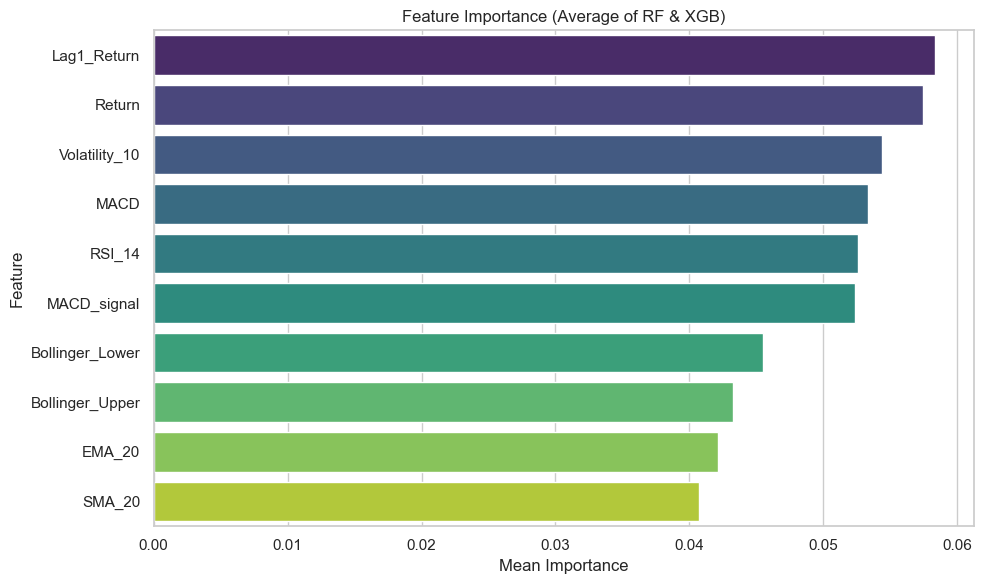

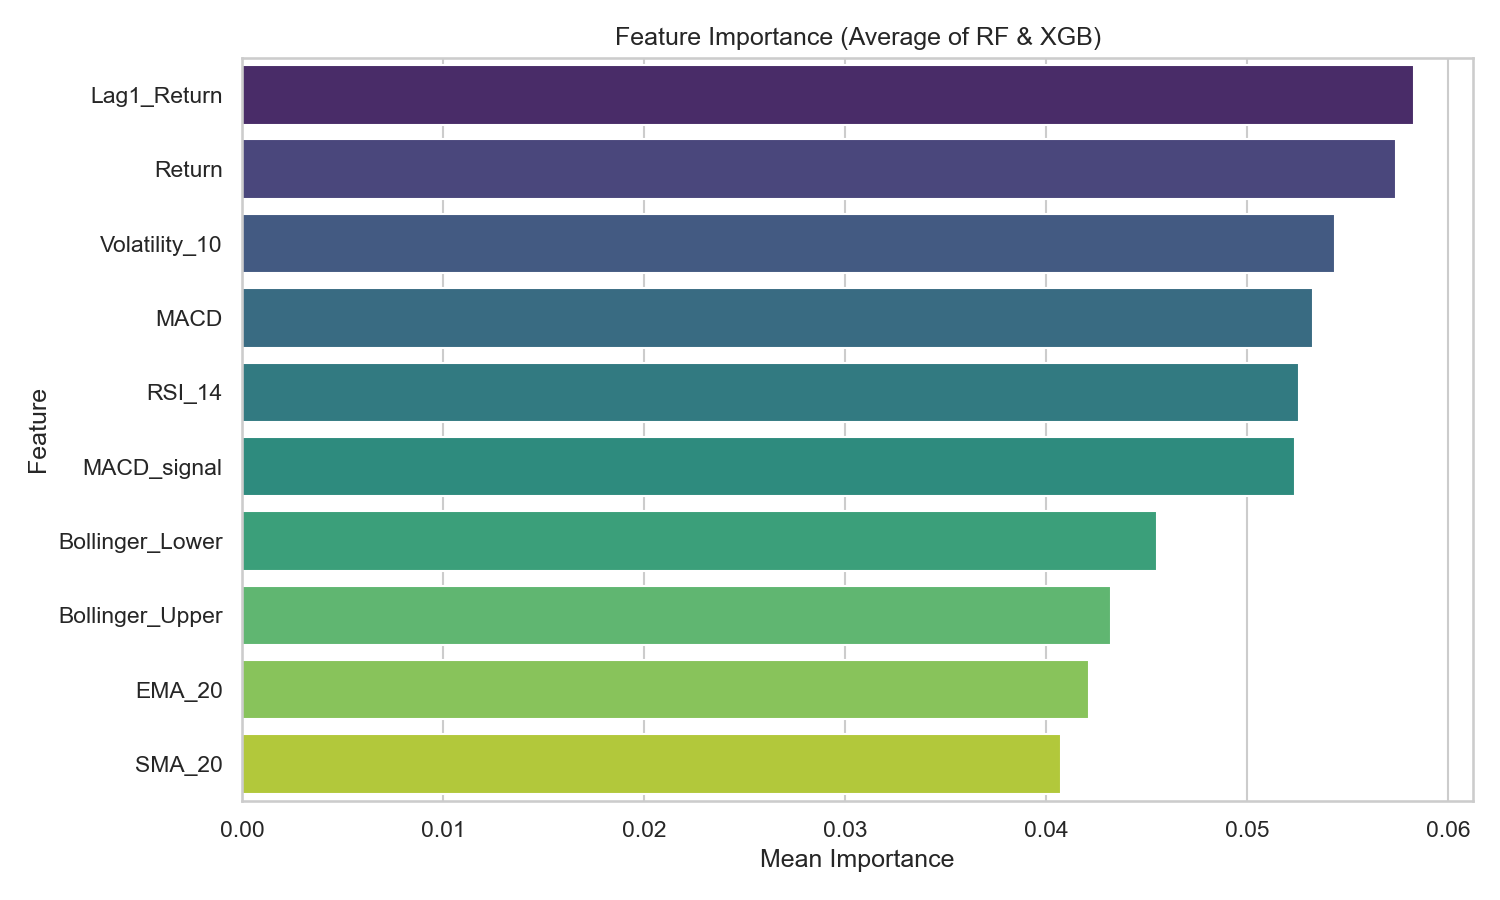


Top 5 features:
                RandomForest  XGBoost  MeanImportance
Feature                                             
Lag1_Return        0.116659      0.0        0.058330
Return             0.114825      0.0        0.057412
Volatility_10      0.108742      0.0        0.054371
MACD               0.106615      0.0        0.053307
RSI_14             0.105129      0.0        0.052564


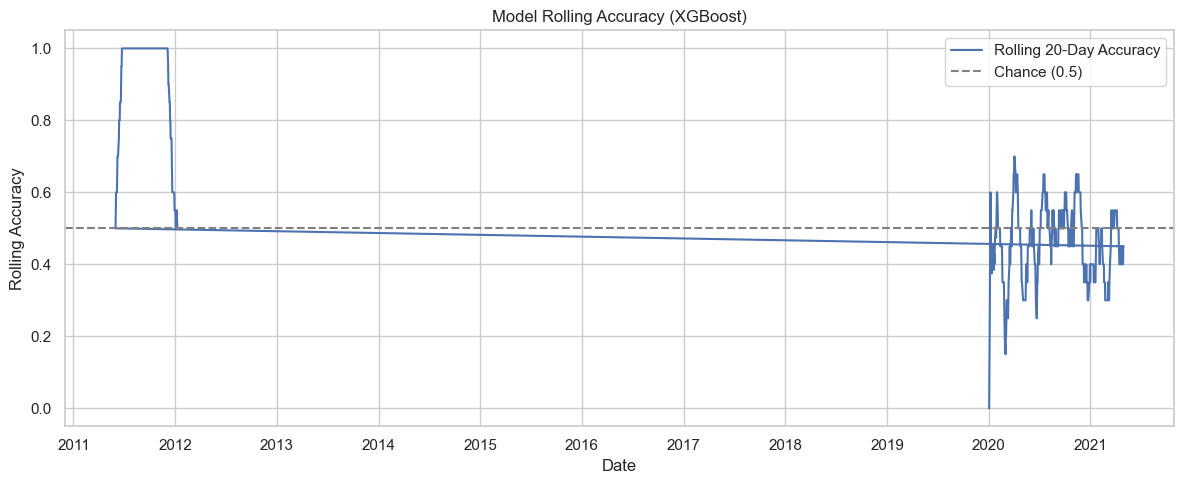

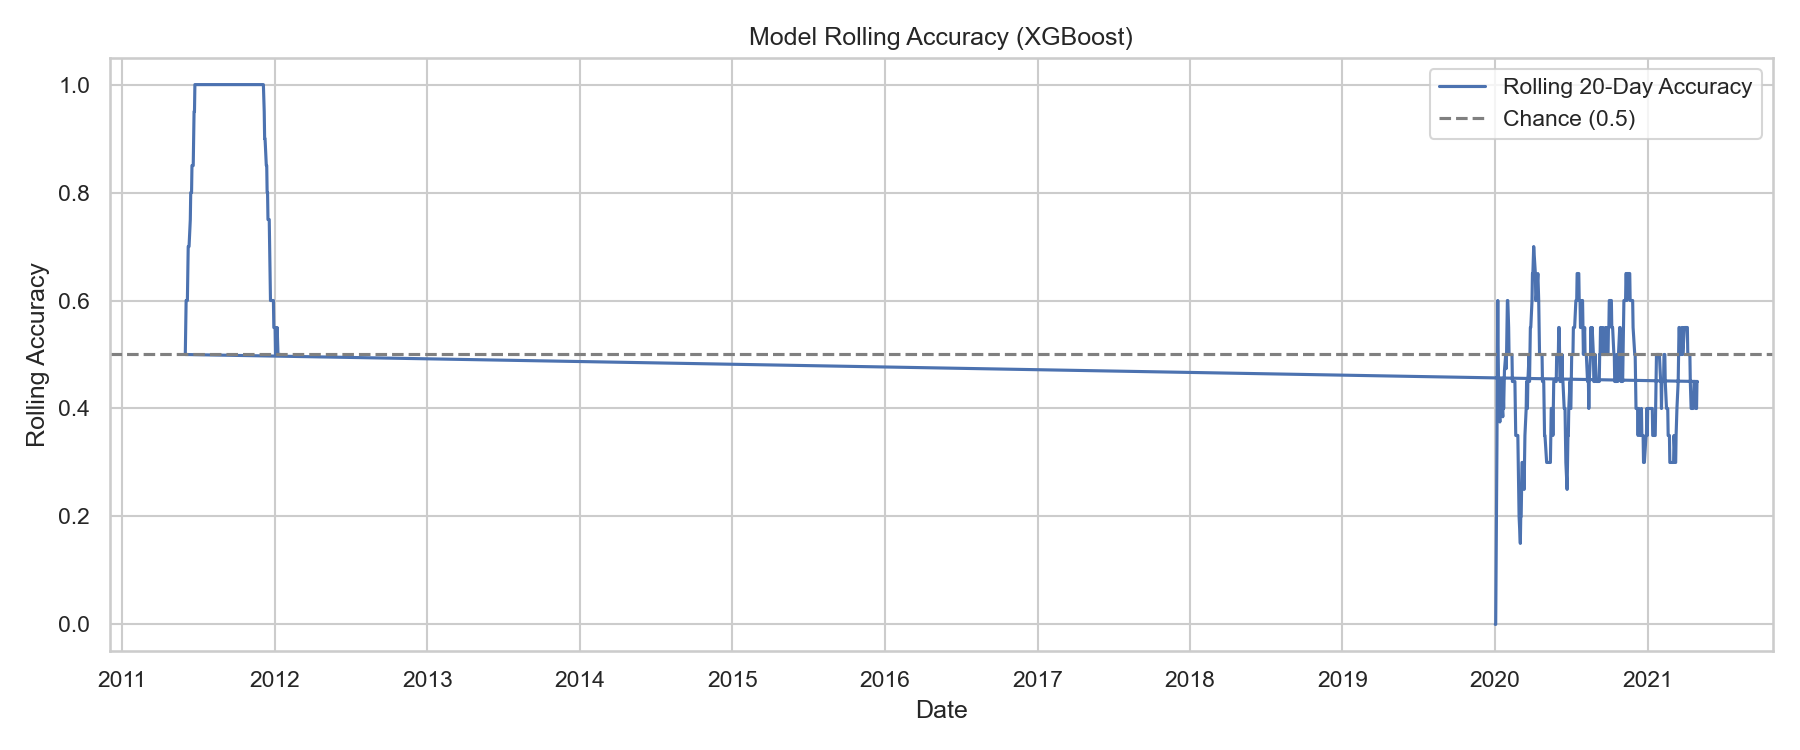

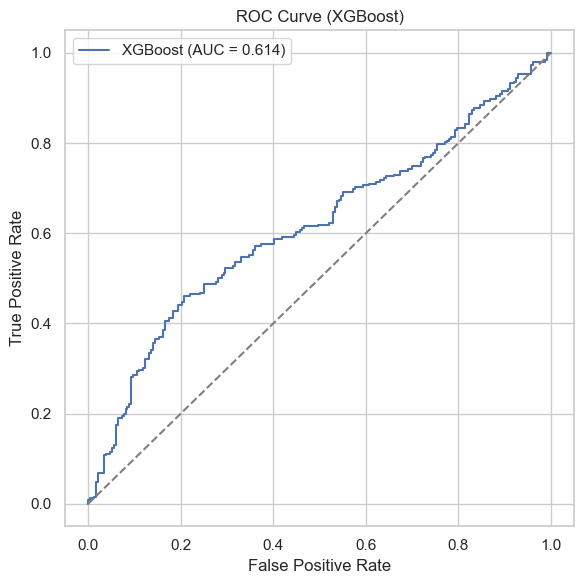

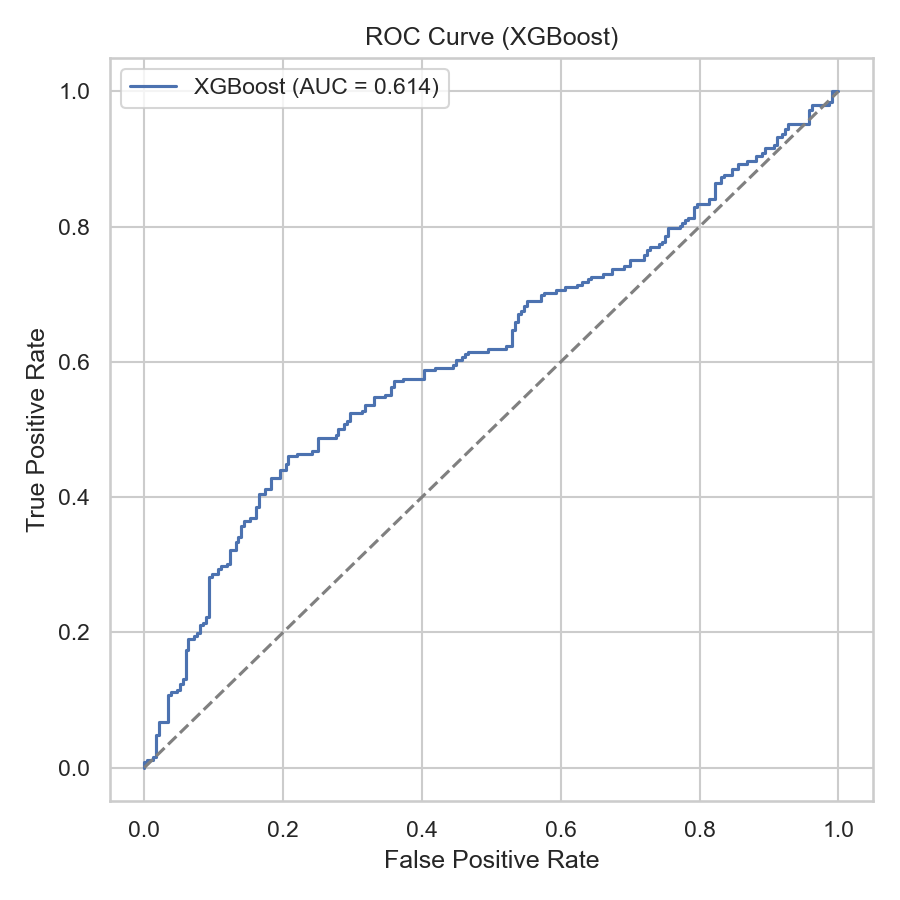

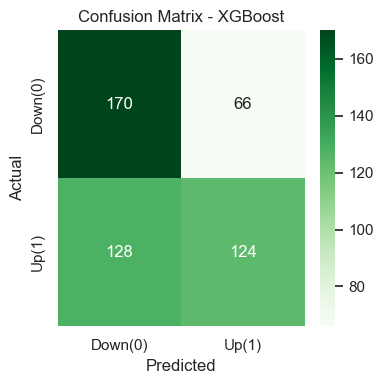

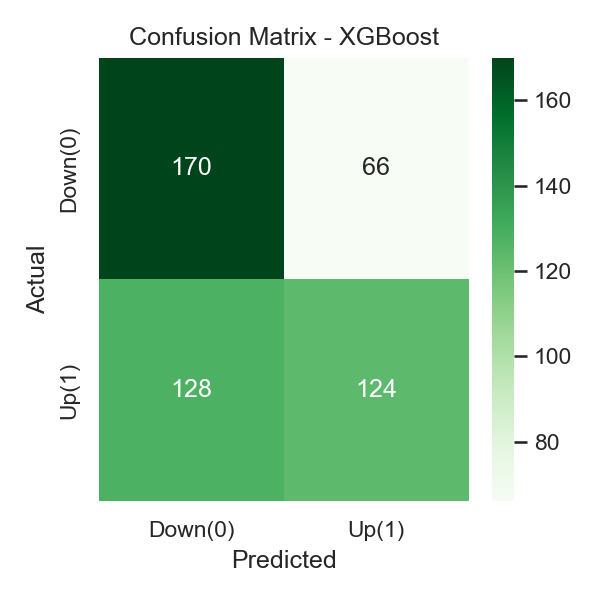


XGBoost Performance:
Accuracy: 0.6024590163934426
F1 Score: 0.5610859728506787
              precision    recall  f1-score   support

           0       0.57      0.72      0.64       236
           1       0.65      0.49      0.56       252

    accuracy                           0.60       488
   macro avg       0.61      0.61      0.60       488
weighted avg       0.61      0.60      0.60       488


Saved files:
- ml_results_plots\conf_matrix_xgb.png
- ml_results_plots\confmat_LightGBM.png
- ml_results_plots\confmat_LogisticRegression.png
- ml_results_plots\confmat_RandomForest.png
- ml_results_plots\confmat_SVM_RBF.png
- ml_results_plots\confmat_XGBoost.png
- ml_results_plots\featimp_LightGBM.png
- ml_results_plots\featimp_LogisticRegression.png
- ml_results_plots\featimp_RandomForest.png
- ml_results_plots\featimp_XGBoost.png
- ml_results_plots\feature_importance_combined.png
- ml_results_plots\roc_all_models.png
- ml_results_plots\roc_xgboost.png
- ml_results_plots\rolling_accu

In [42]:
# visualizations_display_fixed.py
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, f1_score, classification_report
import joblib
from pathlib import Path

# optional IPython display for notebooks
try:
    from IPython.display import Image, display, clear_output
    in_ipython = True
except Exception:
    in_ipython = False

sns.set(style="whitegrid")

OUTPUT_DIR = Path("ml_results_plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# load models
rf = joblib.load(OUTPUT_DIR / "model_RandomForest.pkl")
xgb = joblib.load(OUTPUT_DIR / "model_XGBoost.pkl")
lr = joblib.load(OUTPUT_DIR / "model_LogisticRegression.pkl")

# load data
df = pd.read_csv("equities_with_features.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)

FEATURES = [
    'SMA_20', 'EMA_20', 'RSI_14', 'MACD', 'MACD_signal',
    'Bollinger_Upper', 'Bollinger_Lower', 'Return', 'Lag1_Return', 'Volatility_10'
]

# target
df['Next_Close'] = df.groupby('Symbol')['Close'].shift(-1)
df['Direction'] = (df['Next_Close'] > df['Close']).astype(int)
df = df.dropna(subset=FEATURES + ['Direction']).reset_index(drop=True)

# split same as before
split_idx = int(0.8 * len(df))
if split_idx <= 0 or split_idx >= len(df):
    raise ValueError(f"Bad split index: {split_idx}. Data length: {len(df)}")

X_train, X_test = df[FEATURES].iloc[:split_idx], df[FEATURES].iloc[split_idx:]
y_train, y_test = df['Direction'].iloc[:split_idx], df['Direction'].iloc[split_idx:]
dates = df['Date'].iloc[split_idx:]

print("Dataset lengths -> total:", len(df), "train:", len(X_train), "test:", len(X_test))
print("Features available:", FEATURES)
print("X_test sample:\n", X_test.head())

# -------- FEATURE IMPORTANCE --------
rf_importance = rf.feature_importances_
xgb_importance = xgb.feature_importances_

feature_df = pd.DataFrame({
    'Feature': FEATURES,
    'RandomForest': rf_importance,
    'XGBoost': xgb_importance
}).set_index('Feature')
feature_df['MeanImportance'] = feature_df.mean(axis=1)
feature_df = feature_df.sort_values('MeanImportance', ascending=False)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=feature_df['MeanImportance'], y=feature_df.index, palette='viridis')
ax.set_title('Feature Importance (Average of RF & XGB)')
ax.set_xlabel('Mean Importance')
plt.tight_layout()
fp = OUTPUT_DIR / "feature_importance_combined.png"
plt.savefig(fp, dpi=150)
plt.show()

if in_ipython:
    display(Image(filename=str(fp)))

print("\nTop 5 features:\n", feature_df.head(5))

# -------- ACTUAL vs PREDICTED (Rolling Accuracy) --------
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'Date': dates.values,
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Prob_Up': y_proba
})
results['RollingAcc'] = results['Actual'].eq(results['Predicted']).rolling(window=20, min_periods=1).mean()

plt.figure(figsize=(12,5))
plt.plot(results['Date'], results['RollingAcc'], label='Rolling 20-Day Accuracy')
plt.axhline(0.5, color='gray', linestyle='--', label='Chance (0.5)')
plt.title('Model Rolling Accuracy (XGBoost)')
plt.xlabel('Date')
plt.ylabel('Rolling Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
fp2 = OUTPUT_DIR / "rolling_accuracy.png"
plt.savefig(fp2, dpi=150)
plt.show()

if in_ipython:
    display(Image(filename=str(fp2)))

# -------- ROC & Confusion Matrix --------
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], '--', color='gray')
plt.title('ROC Curve (XGBoost)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
fp3 = OUTPUT_DIR / "roc_xgboost.png"
plt.savefig(fp3, dpi=150)
plt.show()

if in_ipython:
    display(Image(filename=str(fp3)))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Down(0)','Up(1)'], yticklabels=['Down(0)','Up(1)'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
fp4 = OUTPUT_DIR / "conf_matrix_xgb.png"
plt.savefig(fp4, dpi=150)
plt.show()

if in_ipython:
    display(Image(filename=str(fp4)))

# -------- Summary metrics --------
print("\nXGBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# final check - list files saved
print("\nSaved files:")
for p in sorted(OUTPUT_DIR.glob("*.png")):
    print("-", p)
